# Detecting expr1.timer-style plot from expr2.fsize min-fsize data (0602)

Run this notebook on af309 with the `xfold-scripts` kernel. Set `RUN_ROOTS` to one or more `detecting.expr2.fsize/` data directories. The notebook automatically keeps the minimum `fsize_kib` in each host root, then draws the timer histogram/CDF view.


In [2]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RUN_ROOTS = [
    Path('/astrum/home/hpchzy/code/data/20260603/c920bn3/outputDetecting/expr2fsize/walk20/20260603-120320/detecting.expr2.fsize/'),
    Path('/astrum/home/hpchzy/code/data/20260603/camd9554n2/outputDetecting/expr2fsize/walk20/20260603-120348/detecting.expr2.fsize/'),
    Path('/astrum/home/hpchzy/code/data/20260603/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260603-120400/detecting.expr2.fsize/'),
]

TIMER_COLORS = {
    'clock_gettime': '#ff7f0e',
    'cgt': '#ff7f0e',
    'mpi_wtime': '#2ca02c',
    'wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#1f77b4',
    'tsc_native': '#17becf',
    'tsc_asym': '#7f7f7f',
    'cntvct': '#00a6d6',
    'cntvct_fence': '#00a6d6',
    'cntvcto': '#e377c2',
}

HOST_LABELS = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}

DROP_TIMERS = {'cntvct_fence', 'tsc_asym'}
RUN_TAG = 'multi_host_min_fsize' if len(RUN_ROOTS) > 1 else RUN_ROOTS[0].name
for root in RUN_ROOTS:
    print(root)


/astrum/home/hpchzy/code/data/20260603/c920bn3/outputDetecting/expr2fsize/walk20/20260603-120320/detecting.expr2.fsize
/astrum/home/hpchzy/code/data/20260603/camd9554n2/outputDetecting/expr2fsize/walk20/20260603-120348/detecting.expr2.fsize
/astrum/home/hpchzy/code/data/20260603/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260603-120400/detecting.expr2.fsize


In [3]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors='ignore').splitlines():
        if '=' in line:
            k, v = line.split('=', 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors='ignore').splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        try:
            vals.append(float(line.split(',')[-1]))
        except ValueError:
            pass
    return vals


def ta_from_run_dir(run_dir, meta):
    for key in ('ta', 'mu_ns', 'interval_ns'):
        if key in meta:
            try:
                return float(meta[key])
            except ValueError:
                pass
    m = re.search(r'_ta([0-9]+(?:\.[0-9]+)?)', run_dir.name)
    if m:
        return float(m.group(1))
    return math.nan


def ecdf(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.array([]), np.array([])
    xs = np.sort(vals)
    ys = np.arange(1, xs.size + 1) / xs.size
    return xs, ys


In [4]:
rows = []
for run_root in RUN_ROOTS:
    for cdf in sorted(run_root.rglob('*_ta_cdf.csv')):
        run_dir = cdf.parent
        combo_dir = run_dir.parent
        meta = parse_meta(run_dir / 'meta.txt') or parse_meta(combo_dir / 'meta.txt')
        measured = read_values(cdf)
        if not measured:
            continue
        ta = ta_from_run_dir(run_dir, meta)
        rows.append({
            'run_root': str(run_root),
            'host': meta.get('host', run_root.parts[-6] if len(run_root.parts) >= 6 else ''),
            'expr': meta.get('expr_name', run_root.name),
            'np': int(float(meta.get('np', 0) or 0)),
            'timer': meta.get('timer', cdf.parents[2].name),
            'interval_ns': int(float(meta.get('interval_ns', meta.get('mu_ns', 0)) or 0)),
            'fsize_kib': int(float(meta.get('fsize_kib', 0) or 0)),
            'fkern': meta.get('fkern', ''),
            'rkern': meta.get('rkern', ''),
            'walk_id': int(float(meta.get('walk_id', 0) or 0)),
            'ta': ta,
            'measured': measured,
            'theory': [ta] * len(measured),
            'n_measured': len(measured),
            'run_dir': str(run_dir),
        })

raw = pd.DataFrame(rows)
print(f'cdf files: {len(raw)}')
if raw.empty:
    raise RuntimeError('No *_ta_cdf.csv files found under RUN_ROOTS')

raw = raw[~raw['timer'].isin(DROP_TIMERS)].copy()
min_fsize = raw.groupby('host')['fsize_kib'].transform('min')
raw_min = raw[raw['fsize_kib'] == 16].copy()
raw_min['hostname'] = raw_min['host'].map(HOST_LABELS).fillna(raw_min['host'])
print(raw_min.groupby(['host', 'timer', 'fsize_kib']).size().reset_index(name='walk_files').to_string(index=False))
raw_min.head()


cdf files: 4618
       host         timer  fsize_kib  walk_files
    c920bn3 clock_gettime         16          20
    c920bn3        cntvct         16          20
    c920bn3       cntvcto         16          20
    c920bn3     mpi_wtime         16          20
    c920bn3          papi         16          20
    c920bn3        papix6         16          20
 camd9554n2 clock_gettime         16          20
 camd9554n2        likwid         16          20
 camd9554n2     mpi_wtime         16          20
 camd9554n2          papi         16          20
 camd9554n2        papix6         16          20
 camd9554n2           tsc         16          20
cgnr6760pn2 clock_gettime         16          20
cgnr6760pn2        likwid         16          20
cgnr6760pn2     mpi_wtime         16          20
cgnr6760pn2          papi         16          20
cgnr6760pn2        papix6         16          20
cgnr6760pn2           tsc         16          20


,run_root,host,expr,np,timer,interval_ns,fsize_kib,fkern,rkern,walk_id,ta,measured,theory,n_measured,run_dir,hostname
60,/astrum/home/hpchzy/code/data/20260603/c920bn3...,c920bn3,detecting.expr2.fsize,64,clock_gettime,1000,16,copy,none,1,1005.0,"[1030.0, 1030.0, 1030.0, 1030.0, 1030.0, 1030....","[1005.0, 1005.0, 1005.0, 1005.0, 1005.0, 1005....",100,/astrum/home/hpchzy/code/data/20260603/c920bn3...,Kunpeng 920B
61,/astrum/home/hpchzy/code/data/20260603/c920bn3...,c920bn3,detecting.expr2.fsize,64,clock_gettime,1000,16,copy,none,2,984.0,"[1010.0, 1010.0, 1010.0, 1010.0, 1010.0, 1010....","[984.0, 984.0, 984.0, 984.0, 984.0, 984.0, 984...",100,/astrum/home/hpchzy/code/data/20260603/c920bn3...,Kunpeng 920B
62,/astrum/home/hpchzy/code/data/20260603/c920bn3...,c920bn3,detecting.expr2.fsize,64,clock_gettime,1000,16,copy,none,3,1011.0,"[1040.0, 1040.0, 1040.0, 1040.0, 1040.0, 1040....","[1011.0, 1011.0, 1011.0, 1011.0, 1011.0, 1011....",100,/astrum/home/hpchzy/code/data/20260603/c920bn3...,Kunpeng 920B
63,/astrum/home/hpchzy/code/data/20260603/c920bn3...,c920bn3,detecting.expr2.fsize,64,clock_gettime,1000,16,copy,none,4,1014.0,"[1040.0, 1040.0, 1040.0, 1040.0, 1040.0, 1040....","[1014.0, 1014.0, 1014.0, 1014.0, 1014.0, 1014....",100,/astrum/home/hpchzy/code/data/20260603/c920bn3...,Kunpeng 920B
64,/astrum/home/hpchzy/code/data/20260603/c920bn3...,c920bn3,detecting.expr2.fsize,64,clock_gettime,1000,16,copy,none,5,971.0,"[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....","[971.0, 971.0, 971.0, 971.0, 971.0, 971.0, 971...",100,/astrum/home/hpchzy/code/data/20260603/c920bn3...,Kunpeng 920B


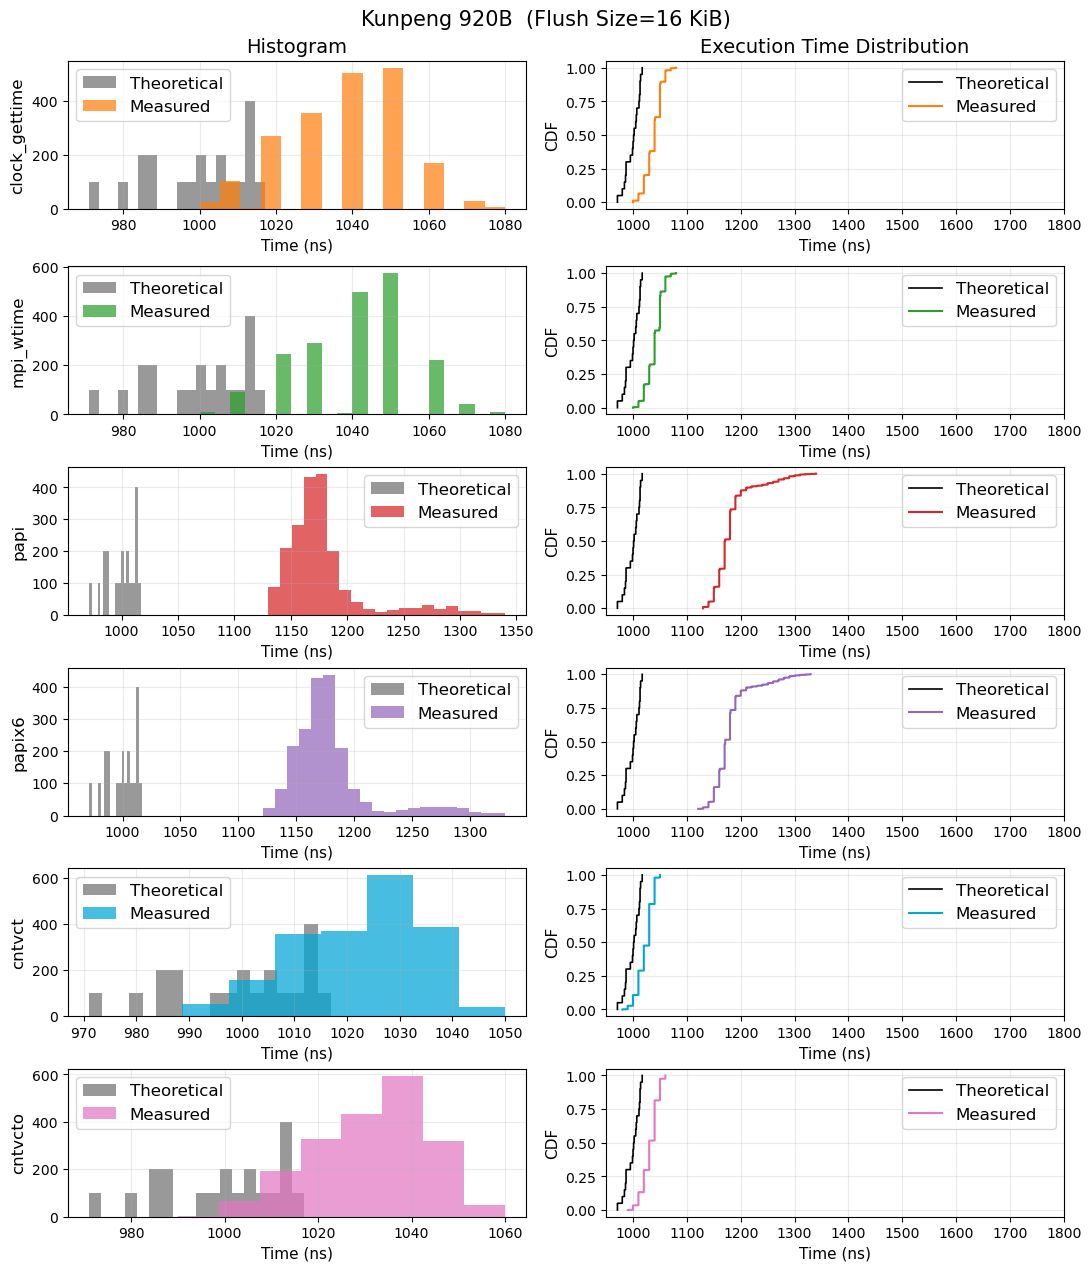

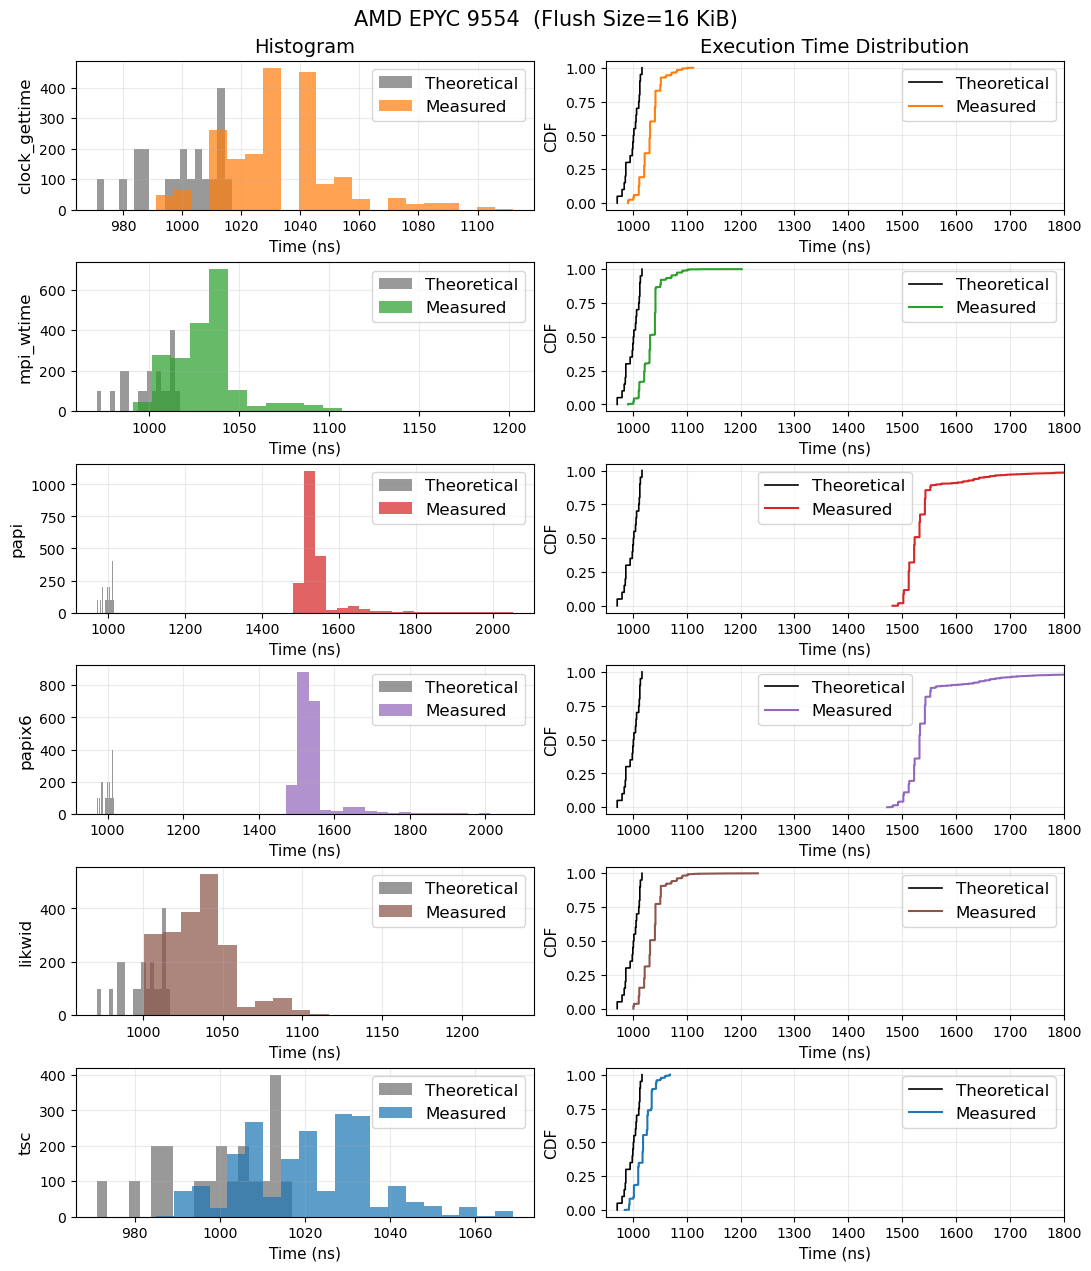

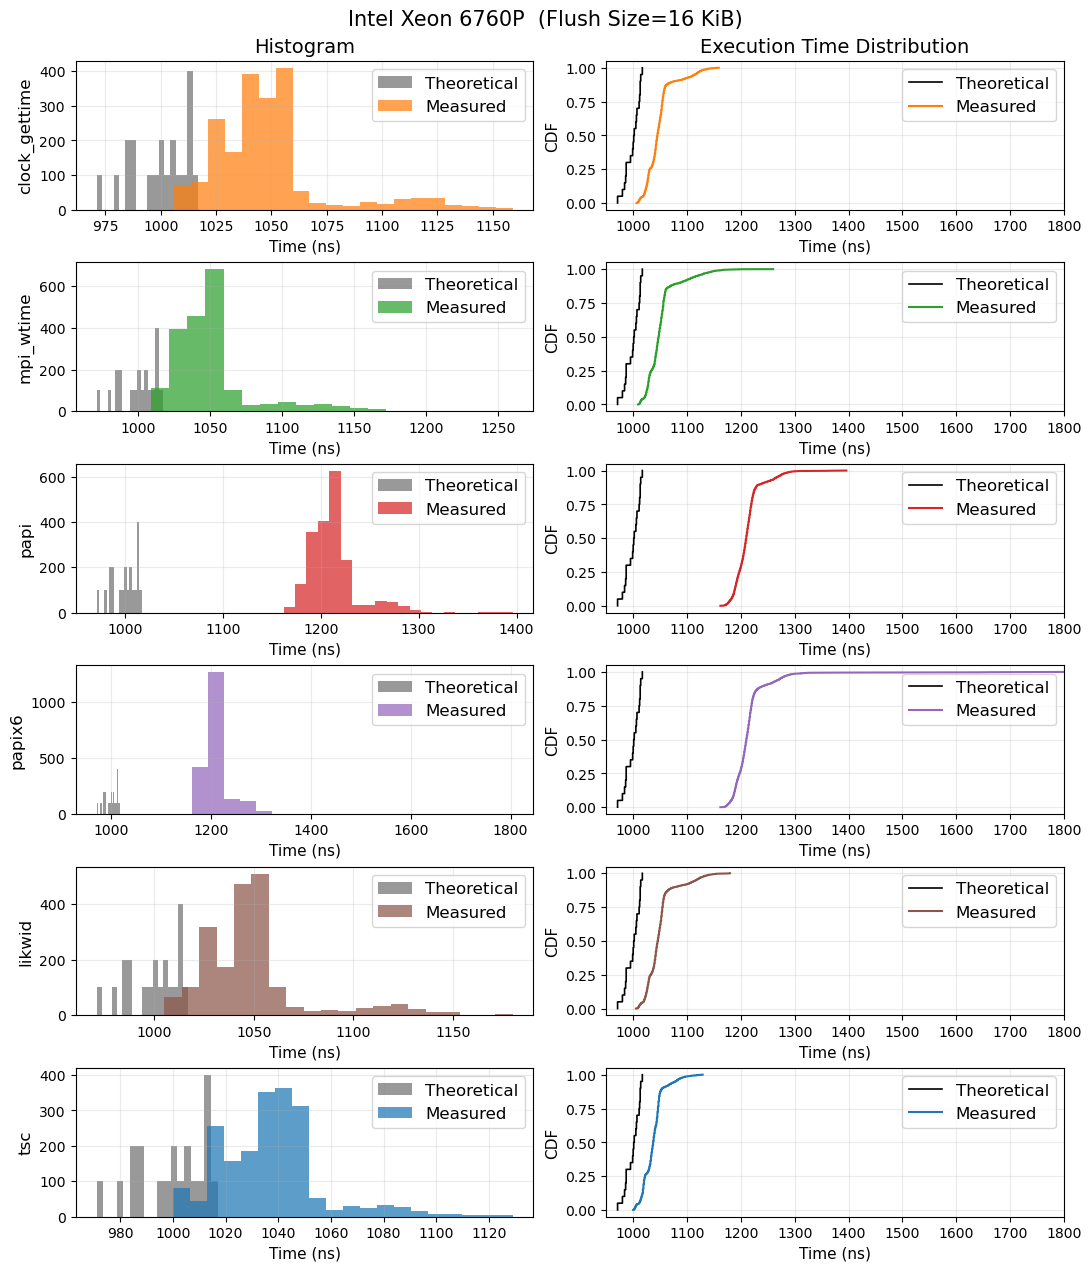

In [5]:
# One figure per host: each timer has histogram on the left and measured/theoretical CDF on the right.
for host, host_df in raw_min.groupby('host', sort=False):
    timers = [t for t in TIMER_COLORS if t in set(host_df['timer'])]
    timers += [t for t in sorted(host_df['timer'].unique()) if t not in timers]
    if not timers:
        continue

    fsize = int(host_df['fsize_kib'].min())
    fig, axes = plt.subplots(len(timers), 2, figsize=(10.8, max(2.4, 2.1 * len(timers))), squeeze=False, constrained_layout=True)
    for row_idx, timer in enumerate(timers):
        tdf = host_df[host_df['timer'] == timer]
        measured = np.array([x for vals in tdf['measured'] for x in vals], dtype=float)


        QUANTILE_DROP = 0.99
        quantile_drop = np.quantile(measured, QUANTILE_DROP)
        measured = measured[measured <= quantile_drop]


        theory = np.array([x for vals in tdf['theory'] for x in vals], dtype=float)
        color = TIMER_COLORS.get(timer)
        ax_hist, ax_cdf = axes[row_idx]

        tbins = min(20, max(3, len(np.unique(theory)))) if theory.size else 3
        ax_hist.hist(theory, bins=tbins, alpha=0.40, color='black', label='Theoretical')
        
        tbins = min(20, max(3, len(np.unique(measured)))) if measured.size else 3
        ax_hist.hist(measured, bins=tbins, alpha=0.72, color=color, label='Measured')
        
        ax_hist.set_ylabel(timer, fontsize=12)
        ax_hist.set_xlabel('Time (ns)', fontsize=11)
        ax_hist.grid(True, alpha=0.25)
        ax_hist.legend(fontsize=12)
        # ax_hist.set_xlim(left=950, right=1800)

        tx, ty = ecdf(theory)
        mx, my = ecdf(measured)
        ax_cdf.plot(tx, ty, linewidth=1.2, color='black', label='Theoretical')
        ax_cdf.plot(mx, my, linewidth=1.5, color=color, label='Measured')
        ax_cdf.set_xlabel('Time (ns)', fontsize=11)
        ax_cdf.set_ylabel('CDF', fontsize=11)
        ax_cdf.grid(True, alpha=0.25)
        ax_cdf.legend(fontsize=12)

        ax_cdf.set_xlim(left=950, right=1800)

    axes[0, 0].set_title('Histogram', fontsize=14)
    axes[0, 1].set_title('Execution Time Distribution', fontsize=14)
    fig.suptitle(f"{HOST_LABELS.get(host, host)}  (Flush Size={fsize} KiB)", fontsize=15)
    plt.show()


In [6]:
# Optional: save the figures by rerunning the plotting cell manually with fig.savefig(...).
# This notebook intentionally shows figures inline and does not replace tex images.
